<div style="font-size: 48px; font-weight: bold" align="center">
💶 💷 💵 💴
💶 💷 💵 💴
💶 💷 💵 💴
💶 💷
<br/>
💸 Détection automatique de faux billets 💸
<br/>
💵 💴
💶 💷 💵 💴
💶 💷 💵 💴
💶 💷 💵 💴
</div>

# Import des librairies et paramètres généraux

In [1]:
import numpy as np
import pandas as pd

In [2]:
# import scipy
# import statsmodels
import pingouin as pg

In [3]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import seaborn as sns

In [4]:
import sklearn

In [5]:
sklearn.set_config(transform_output="pandas")

In [6]:
random_state = 100

In [7]:
data_path = "../data"

# Chargement des données

In [8]:
df = pd.read_csv(f"{data_path}/raw/billets.csv", sep=";")
df

,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
0,True,171.81,104.86,104.95,4.52,2.89,112.83
1,True,171.46,103.36,103.66,3.77,2.99,113.09
2,True,172.69,104.48,103.50,4.40,2.94,113.16
3,True,171.36,103.91,103.94,3.62,3.01,113.51
4,True,171.73,104.28,103.46,4.04,3.48,112.54
...,...,...,...,...,...,...,...
1495,False,171.75,104.38,104.17,4.42,3.09,111.28
1496,False,172.19,104.63,104.44,5.27,3.37,110.97
1497,False,171.80,104.01,104.12,5.51,3.36,111.95
1498,False,172.06,104.28,104.06,5.17,3.46,112.25


# Analyse exploratoire des données

## Vue d'ensemble

In [9]:
df.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   is_genuine    1500 non-null   bool   
 1   diagonal      1500 non-null   float64
 2   height_left   1500 non-null   float64
 3   height_right  1500 non-null   float64
 4   margin_low    1463 non-null   float64
 5   margin_up     1500 non-null   float64
 6   length        1500 non-null   float64
dtypes: bool(1), float64(6)
memory usage: 71.9 KB


In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
diagonal,1500.0,171.958440,0.305195,171.04,171.750,171.96,172.17,173.01
height_left,1500.0,104.029533,0.299462,103.14,103.820,104.04,104.23,104.88
height_right,1500.0,103.920307,0.325627,102.82,103.710,103.92,104.15,104.95
margin_low,1463.0,4.485967,0.663813,2.98,4.015,4.31,4.87,6.90
margin_up,1500.0,3.151473,0.231813,2.27,2.990,3.14,3.31,3.91
length,1500.0,112.678500,0.872730,109.49,112.030,112.96,113.34,114.44


In [11]:
df["is_genuine"].value_counts()

is_genuine
True     1000
False     500
Name: count, dtype: int64

In [12]:
cnt = df.shape[0]
cnt_t = ( df["is_genuine"]).sum()
cnt_f = (~df["is_genuine"]).sum()
for column in df.columns:
    cnt_na = df[column].isna().sum()
    if cnt_na > 0:
        cnt_na_t = df[  df["is_genuine"] ][column].isna().sum()
        cnt_na_f = df[ ~df["is_genuine"] ][column].isna().sum()
        print(f"Variable {column} : {cnt_na}/{cnt} valeurs manquantes ({cnt_na/cnt:.2%})")
        print(f"  - Vrais billets : {cnt_na_t}/{cnt_t} valeurs manquantes ({cnt_na_t/cnt_t:.2%})")
        print(f"  - Faux billets : {cnt_na_f}/{cnt_f} valeurs manquantes ({cnt_na_f/cnt_f:.2%})")

Variable margin_low : 37/1500 valeurs manquantes (2.47%)
  - Vrais billets : 29/1000 valeurs manquantes (2.90%)
  - Faux billets : 8/500 valeurs manquantes (1.60%)


## Différences entre les vrais/faux billets

In [13]:
def test_quanti_binary(df, *, quanti, binary, alpha=0.05):
    keys = np.sort(df[binary].unique())
    assert len(keys) == 2, f"⚠️ La variable qualitative n'est pas binaire ({len(keys)} valeur[s])."
    groups = { key: df[ (df[binary] == key) ][quanti].dropna() for key in keys }
    normal_test_result = pg.normality(df, dv=quanti, group=binary, method="shapiro", alpha=alpha)
    print(f"ℹ️ [Shapiro-Wilk] {normal_test_result.normal.sum()}/2 groupes suivent une distribution normale.")
    if normal_test_result.normal.all():
        t_test_result = pg.ttest(*groups.values()).iloc[0]
        p_value = t_test_result.p_val
        if p_value < alpha:
            print("✅ [Test T] Différence de groupes significative")
        else:
            print("❌ [Test T] Différence de groupes non significative")
        d = abs(t_test_result.cohen_d)
        if d < 0.2:
            print(f"🌑 [d de Cohen = {d:.3f}] Effet négligeable")
        elif d < 0.5:
            print(f"🌘 [d de Cohen = {d:.3f}] Effet faible")
        elif d < 0.8:
            print(f"🌗 [d de Cohen = {d:.3f}] Effet modéré")
        else:
            print(f"🌖 [d de Cohen = {d:.3f}] Effet fort")
    else:
        u_test_result = pg.mwu(*groups.values()).iloc[0]
        p_value = u_test_result.p_val
        if p_value < alpha:
            print("✅ [Test U de Mann-Whitney] Différence de groupes significative")
        else:
            print("❌ [Test U de Mann-Whitney] Différence de groupes non significative")
        r = abs(u_test_result.RBC)
        if r < 0.1:
            print(f"🌑 [rank-biserial correlation = {r:.3f}] Effet négligeable")
        elif r < 0.3:
            print(f"🌘 [rank-biserial correlation = {r:.3f}] Effet faible")
        elif r < 0.5:
            print(f"🌗 [rank-biserial correlation = {r:.3f}] Effet modéré")
        else:
            print(f"🌖 [rank-biserial correlation = {r:.3f}] Effet fort")

In [14]:
for column in df.columns[1:]:
    print()
    print(column)
    test_quanti_binary(df, quanti=column, binary="is_genuine")
print()


diagonal
ℹ️ [Shapiro-Wilk] 2/2 groupes suivent une distribution normale.
✅ [Test T] Différence de groupes significative
🌘 [d de Cohen = 0.284] Effet faible

height_left
ℹ️ [Shapiro-Wilk] 1/2 groupes suivent une distribution normale.
✅ [Test U de Mann-Whitney] Différence de groupes significative
🌗 [rank-biserial correlation = 0.485] Effet modéré

height_right
ℹ️ [Shapiro-Wilk] 2/2 groupes suivent une distribution normale.
✅ [Test T] Différence de groupes significative
🌖 [d de Cohen = 1.176] Effet fort

margin_low
ℹ️ [Shapiro-Wilk] 2/2 groupes suivent une distribution normale.
✅ [Test T] Différence de groupes significative
🌖 [d de Cohen = 2.663] Effet fort

margin_up
ℹ️ [Shapiro-Wilk] 2/2 groupes suivent une distribution normale.
✅ [Test T] Différence de groupes significative
🌖 [d de Cohen = 1.616] Effet fort

length
ℹ️ [Shapiro-Wilk] 2/2 groupes suivent une distribution normale.
✅ [Test T] Différence de groupes significative
🌖 [d de Cohen = 3.410] Effet fort



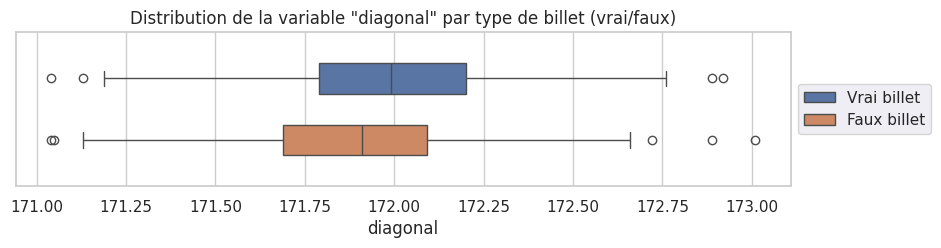

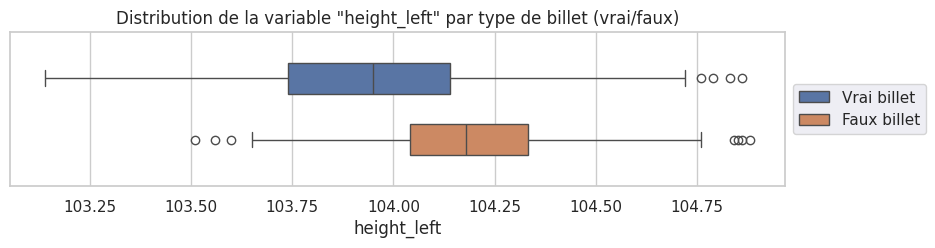

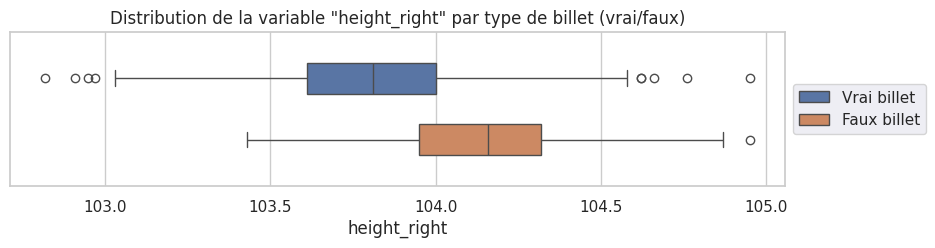

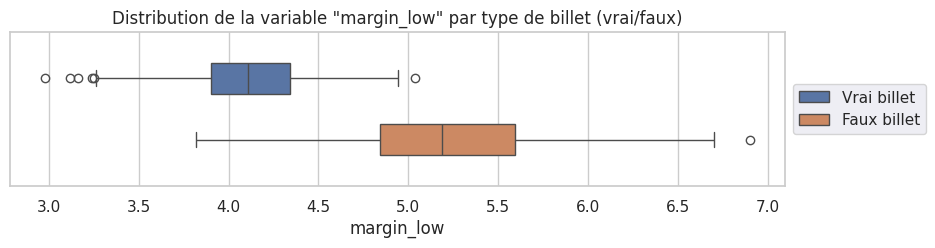

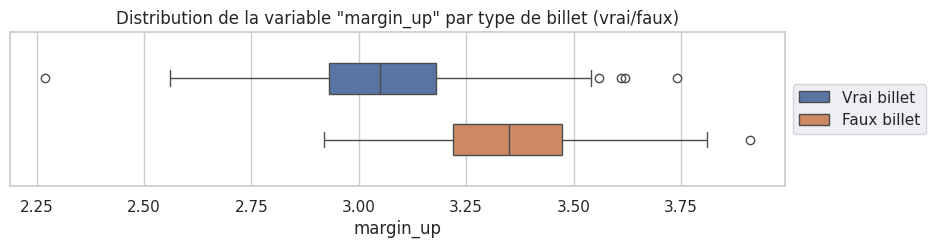

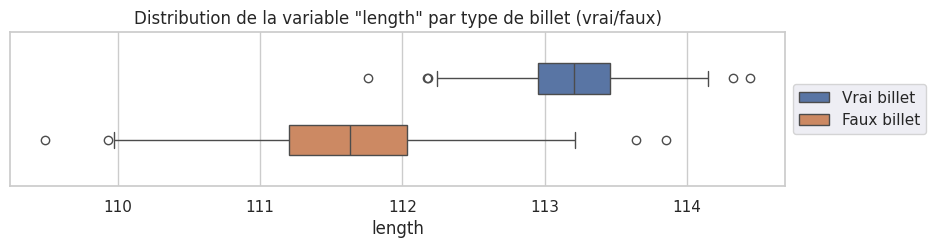

In [15]:
hue = df["is_genuine"].map(["Faux billet","Vrai billet"].__getitem__)
for column in df.columns:
    if column != "is_genuine":
        sns.set(style="whitegrid")
        fig, ax = plt.subplots(figsize=(10,2))
        sns.boxplot(df, x=column, hue=hue, gap=0.5, ax=ax)
        plt.title(f'Distribution de la variable "{column}" par type de billet (vrai/faux)')
        sns.set(style="darkgrid")
        plt.legend(loc="center left", bbox_to_anchor=(1,0.5))
        plt.show()

## Corrélations entre les variables

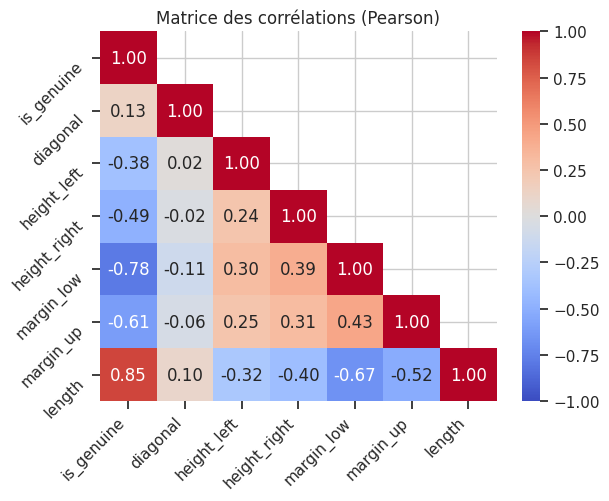

In [16]:
sns.set(style="whitegrid")
sns.heatmap(
    df.corr(method="pearson"), annot=True, fmt=".2f", vmin=-1, vmax=+1, cmap="coolwarm",
    mask=np.tri(df.shape[1], k=-1).T,
)
plt.tick_params(bottom=True, left=True)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=45, va="top")
plt.title("Matrice des corrélations (Pearson)")
plt.show()

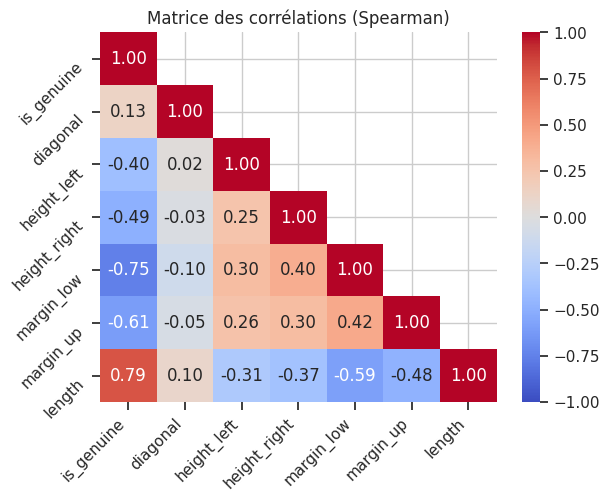

In [17]:
sns.set(style="whitegrid")
sns.heatmap(
    df.corr(method="spearman"), annot=True, fmt=".2f", vmin=-1, vmax=+1, cmap="coolwarm",
    mask=np.tri(df.shape[1], k=-1).T,
)
plt.tick_params(bottom=True, left=True)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=45, va="top")
plt.title("Matrice des corrélations (Spearman)")
plt.show()

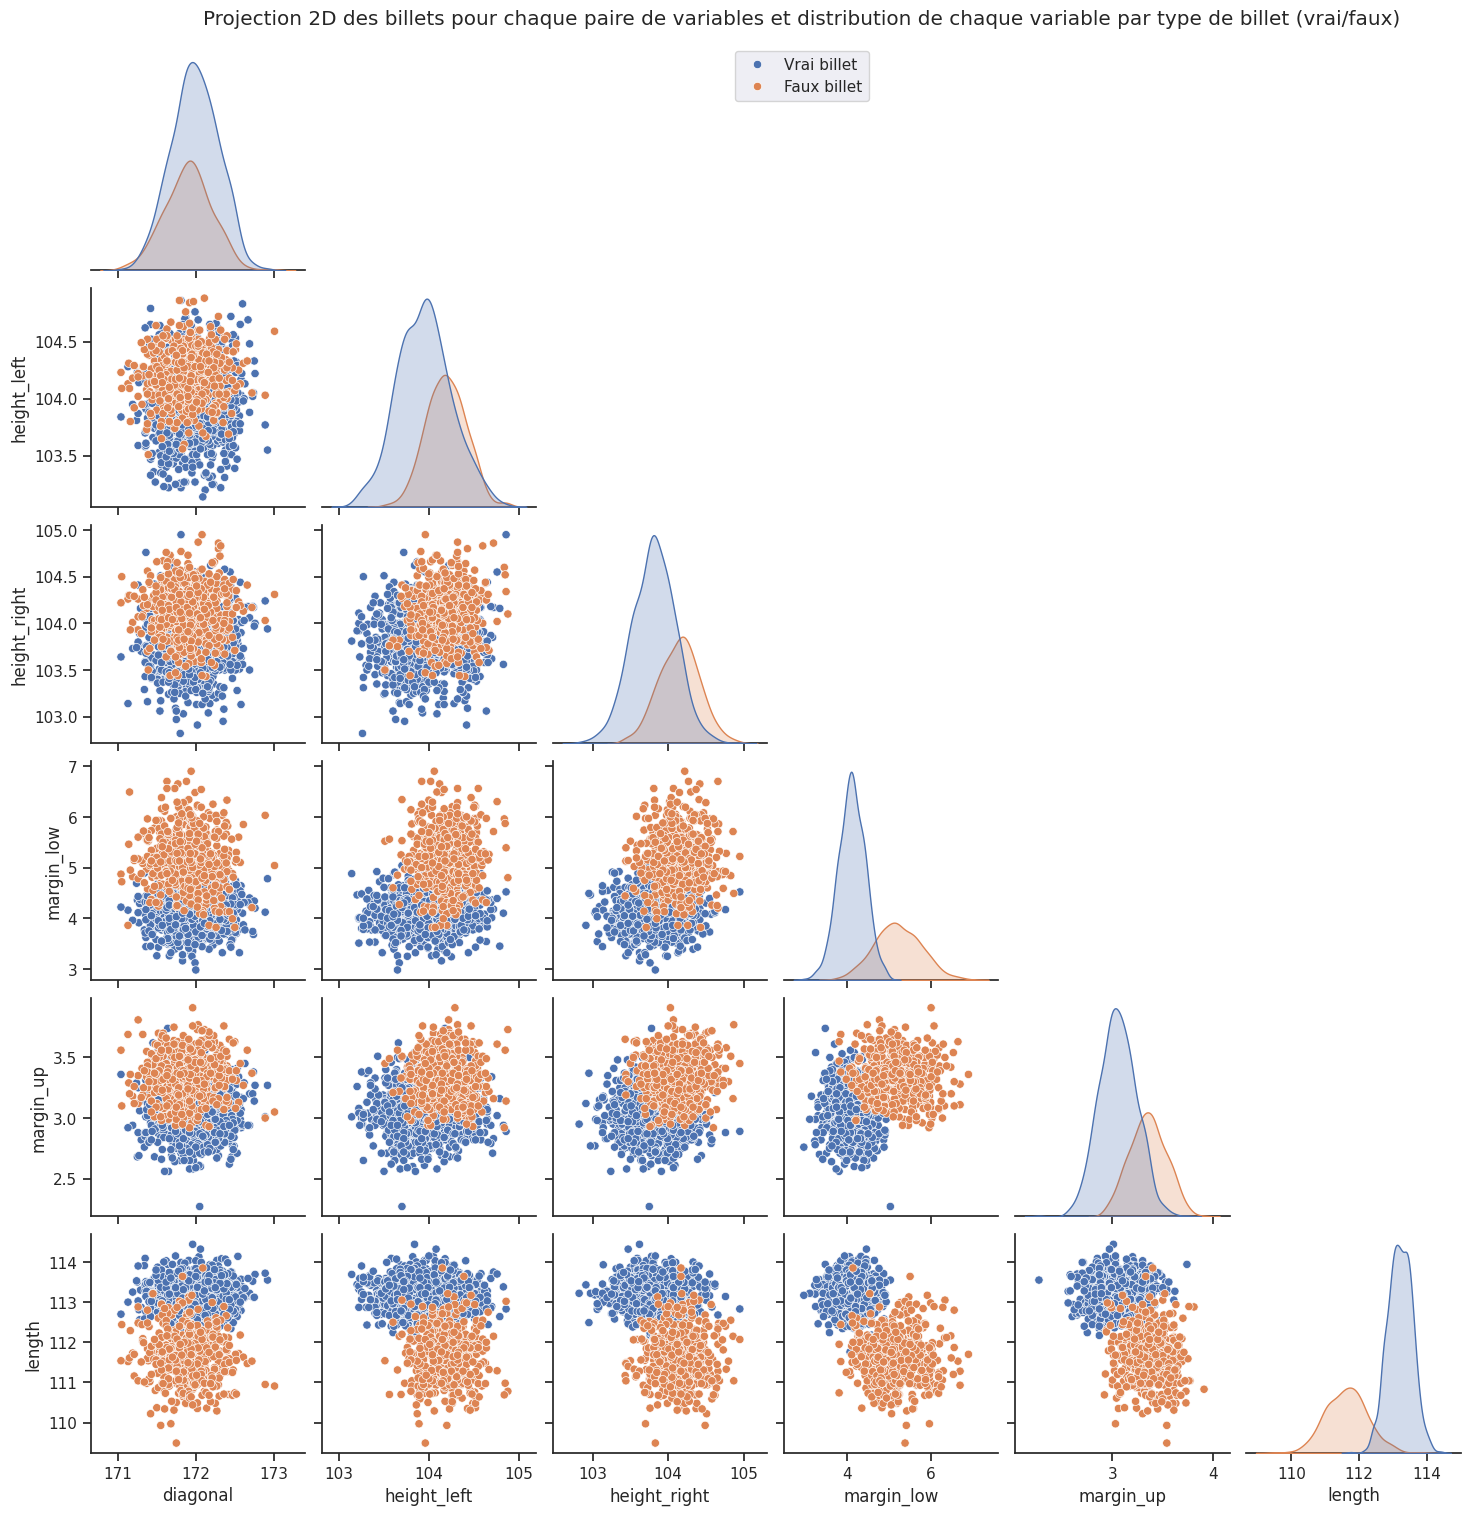

In [18]:
df_pairplot = df.copy()
df_pairplot["genuine"] = df_pairplot.pop("is_genuine").map(["Faux billet","Vrai billet"].__getitem__)
sns.set(style="ticks")
grid = sns.pairplot(df_pairplot, hue="genuine", hue_order=["Vrai billet","Faux billet"], corner=True)
plt.suptitle(
    "Projection 2D des billets pour chaque paire de variables et distribution de chaque variable par type de billet (vrai/faux)",
    x=0.5, y=1, va="bottom",
)
sns.set(style="darkgrid")
grid._legend.set(visible=False)
plt.figlegend(handles=grid._legend.legend_handles, loc="upper center", bbox_to_anchor=(0.5,0.99))
plt.show()

# Prétraitement

## Séparation des données d'entrée (X) des données de sortie (y)

Bien que la colonne "is_genuine" indique si un billet est authentique ou non, elle n'est pas conforme à la définition standard en classification.

La classe positive (valeur réelle ou prédite = vrai) doit correspondre à ce que l'on souhaite détecter (ici, un faux billet).

C'est pourquoi je choisis d'inverser (négation booléenne) la cible en "is_fake".
Cela permet notamment d'interpréter les scores de rappel et de précision correctement.

In [19]:
X = df.copy()
y = ~X.pop("is_genuine")
y.name = "is_fake"

In [20]:
X

,diagonal,height_left,height_right,margin_low,margin_up,length
0,171.81,104.86,104.95,4.52,2.89,112.83
1,171.46,103.36,103.66,3.77,2.99,113.09
2,172.69,104.48,103.50,4.40,2.94,113.16
3,171.36,103.91,103.94,3.62,3.01,113.51
4,171.73,104.28,103.46,4.04,3.48,112.54
...,...,...,...,...,...,...
1495,171.75,104.38,104.17,4.42,3.09,111.28
1496,172.19,104.63,104.44,5.27,3.37,110.97
1497,171.80,104.01,104.12,5.51,3.36,111.95
1498,172.06,104.28,104.06,5.17,3.46,112.25


In [21]:
y.to_frame()

,is_fake
0,False
1,False
2,False
3,False
4,False
...,...
1495,True
1496,True
1497,True
1498,True


## Séparation du jeu de données (entraînement/test)

In [22]:
from sklearn.model_selection import train_test_split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.20, random_state=random_state)
print("X_train", X_train.shape)
print("y_train", y_train.shape)
print("X_test" , X_test .shape)
print("y_test" , y_test .shape)

X_train (1200, 6)
y_train (1200,)
X_test (300, 6)
y_test (300,)


In [24]:
y_train.value_counts()

is_fake
False    800
True     400
Name: count, dtype: int64

In [25]:
y_test.value_counts()

is_fake
False    200
True     100
Name: count, dtype: int64

## Imputation des valeurs manquantes

In [26]:
from sklearn.impute import SimpleImputer

In [27]:
imputer = SimpleImputer(strategy="mean")
imputer

,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'mean'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False


In [28]:
imputer.fit(X_train)
imputer

,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'mean'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](6,)","['diagonal','height_left','height_right','margin_low','margin_up','length']"
indicator_ indicator_: :class:`~sklearn.impute.MissingIndicator`Indicator used to add binary indicators for missing values.`None` if `add_indicator=False`.,NoneType,None
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
"statistics_ statistics_: array of shape (n_features,)The imputation fill value for each feature.Computing statistics can result in `np.nan` values.During :meth:`transform`, features corresponding to `np.nan`statistics will be discarded.","ndarray[float64](6,)","[171.96,104.03,103.92, 4.49, 3.15,112.68]"


In [29]:
X_train = pd.DataFrame(imputer.transform(X_train), index=X_train.index, columns=X_train.columns)
X_train.info(verbose=True)

<class 'pandas.DataFrame'>
Index: 1200 entries, 260 to 476
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   diagonal      1200 non-null   float64
 1   height_left   1200 non-null   float64
 2   height_right  1200 non-null   float64
 3   margin_low    1200 non-null   float64
 4   margin_up     1200 non-null   float64
 5   length        1200 non-null   float64
dtypes: float64(6)
memory usage: 65.6 KB


In [30]:
X_test = pd.DataFrame(imputer.transform(X_test), index=X_test.index, columns=X_test.columns)
X_test.info(verbose=True)

<class 'pandas.DataFrame'>
Index: 300 entries, 944 to 17
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   diagonal      300 non-null    float64
 1   height_left   300 non-null    float64
 2   height_right  300 non-null    float64
 3   margin_low    300 non-null    float64
 4   margin_up     300 non-null    float64
 5   length        300 non-null    float64
dtypes: float64(6)
memory usage: 16.4 KB


## Standardisation

In [31]:
from sklearn.preprocessing import StandardScaler

In [32]:
std_scaler = StandardScaler()
std_scaler

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [33]:
std_scaler.fit(X_train)
std_scaler

StandardScaler()

In [34]:
X_train = pd.DataFrame(std_scaler.transform(X_train), index=X_train.index, columns=X_train.columns)
X_train.describe().T[["mean","std"]].round(2)

,mean,std
diagonal,0.0,1.0
height_left,-0.0,1.0
height_right,-0.0,1.0
margin_low,-0.0,1.0
margin_up,-0.0,1.0
length,-0.0,1.0


In [35]:
X_test = pd.DataFrame(std_scaler.transform(X_test), index=X_test.index, columns=X_test.columns)
X_test.describe().T[["mean","std"]].round(2)

,mean,std
diagonal,-0.03,0.95
height_left,0.00,1.03
height_right,-0.01,0.99
margin_low,-0.04,0.97
margin_up,-0.01,1.03
length,0.00,1.01


## Rééquilibrage du jeu d'entraînement

On observe qu'il y a 2 fois plus de vrais billets que de faux billets.
Il est possible de rééquilibrer le jeu d'entraînement :

- par sur-échantillonnage *(duplication des faux billets ; voir blocs de code désactivés ci-dessous)*
- par sous-échantillonnage *(suppression de la moitié des vrais billets)*

Finalement, une autre approche a été retenue : hyper-paramètre `class_weight="balanced"` avec les modèles compatibles (régression logistique, forêt aléatoire).

# Modèles

In [36]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

In [37]:
def confusion(y_true, y_pred, model_name, subset_name):
    print(classification_report(y_true, y_pred, target_names=["Vrai billet","Faux billet"]))
    sns.set(style="dark")
    cm = confusion_matrix(y_true, y_pred, labels=model_lr.classes_)
    cmd = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[ "Faux billet" if class_ else "Vrai billet" for class_ in model_lr.classes_ ],
    ).plot()
    cmd.ax_.images[0].set_clim(0, cm.sum(axis=1).max())
    plt.title(f"Matrice de confusion - Modèle {model_name} - {subset_name}")
    plt.show()

In [38]:
def proba_histplot(y_proba, model_name, subset_name):
    sns.set(style="darkgrid")
    sns.histplot(y_proba, binwidth=1e-2, binrange=(0-.5e-2, 1+.5e-2))
    plt.ylim(0, y_proba.shape[0])
    plt.title(f"Histogramme des probabilités - Modèle {model_name} - {subset_name}")
    plt.show()

In [39]:
from sklearn.metrics import roc_curve, roc_auc_score

In [40]:
def roc_lineplot(y_true, y_proba, model_name, subset_name):
    fpr, tpr, thresholds = roc_curve(y_true, y_proba)
    score = roc_auc_score(y_true, y_proba)
    sns.set(style="darkgrid")
    fix, ax = plt.subplots()
    ax.set_aspect("equal", adjustable="box")
    plt.plot([0,1], [0,1], color="white")
    plt.plot(fpr, tpr)
    plt.xlabel("Taux de faux positifs")
    plt.ylabel("Taux de vrais positifs")
    ax.xaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
    plt.title(f"Courbe ROC (AUC = {score:.2%}) - Modèle {model_name} - {subset_name}")
    plt.show()

## Modèles supervisés

### LogisticRegression

In [41]:
from sklearn.linear_model import LogisticRegression

In [42]:
model_lr = LogisticRegression(C=2, class_weight="balanced", max_iter=1000)
model_lr

,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",2
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [43]:
model_lr.fit(X_train, y_train)
model_lr

,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",2
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [44]:
y_train_pred_lr = model_lr.predict(X_train)
y_test_pred_lr = model_lr.predict(X_test)

              precision    recall  f1-score   support

 Vrai billet       0.99      0.99      0.99       800
 Faux billet       0.99      0.98      0.99       400

    accuracy                           0.99      1200
   macro avg       0.99      0.99      0.99      1200
weighted avg       0.99      0.99      0.99      1200



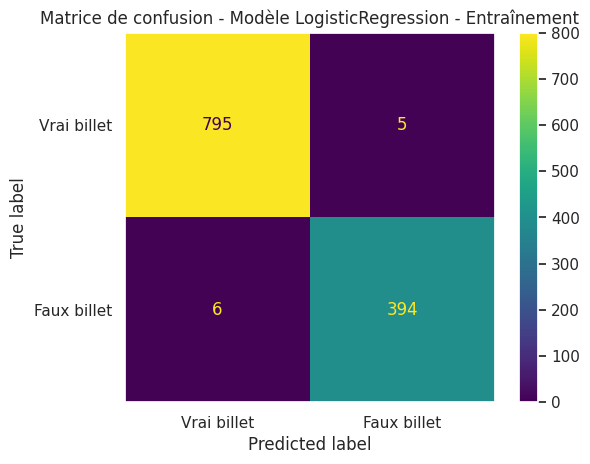

In [45]:
confusion(y_train, y_train_pred_lr, "LogisticRegression", "Entraînement")

              precision    recall  f1-score   support

 Vrai billet       0.99      0.99      0.99       200
 Faux billet       0.98      0.99      0.99       100

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300



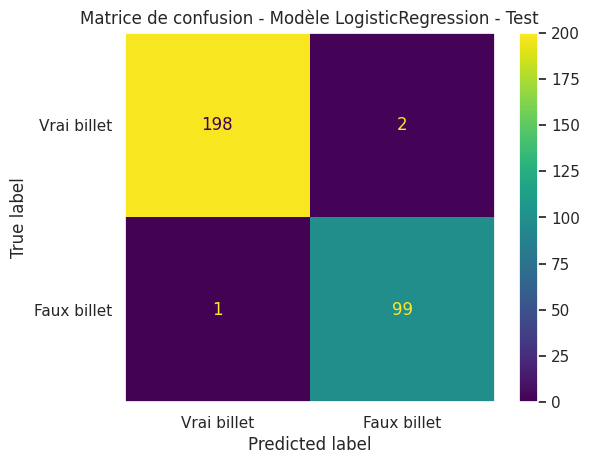

In [46]:
confusion(y_test, y_test_pred_lr, "LogisticRegression", "Test")

In [47]:
y_train_proba_lr = model_lr.predict_proba(X_train)[:,1]
y_test_proba_lr = model_lr.predict_proba(X_test)[:,1]

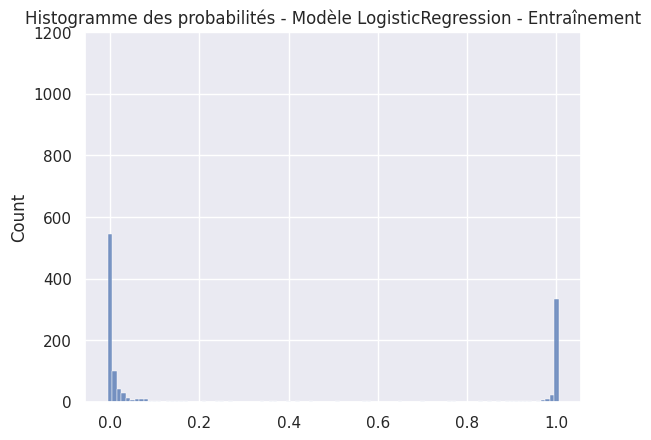

In [48]:
proba_histplot(y_train_proba_lr, "LogisticRegression", "Entraînement")

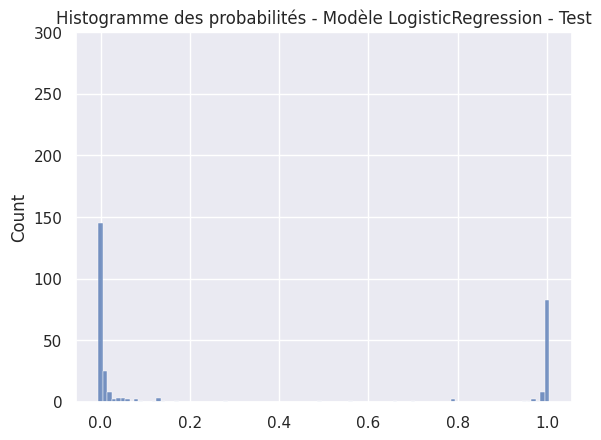

In [49]:
proba_histplot(y_test_proba_lr, "LogisticRegression", "Test")

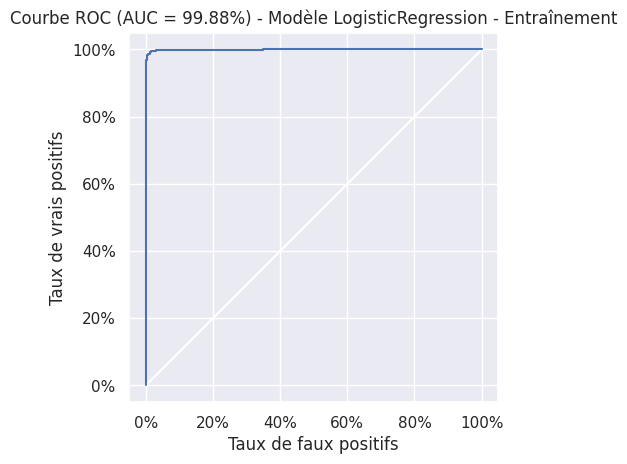

In [50]:
roc_lineplot(y_train, y_train_proba_lr, "LogisticRegression", "Entraînement")

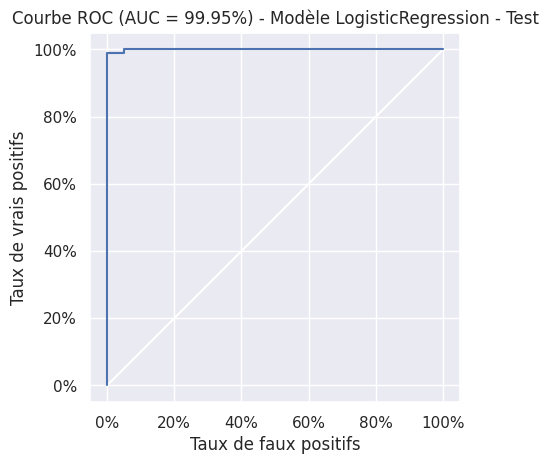

In [51]:
roc_lineplot(y_test, y_test_proba_lr, "LogisticRegression", "Test")

### KNeighborsClassifier

In [52]:
from sklearn.neighbors import KNeighborsClassifier

In [53]:
model_knn = KNeighborsClassifier(n_neighbors=15)
model_knn

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",15
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None


In [54]:
model_knn.fit(X_train, y_train)
model_knn

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",15
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[bool](2,)","[False, True]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [55]:
y_train_pred_knn = model_knn.predict(X_train)
y_test_pred_knn = model_knn.predict(X_test)

              precision    recall  f1-score   support

 Vrai billet       0.99      1.00      0.99       800
 Faux billet       0.99      0.97      0.98       400

    accuracy                           0.99      1200
   macro avg       0.99      0.99      0.99      1200
weighted avg       0.99      0.99      0.99      1200



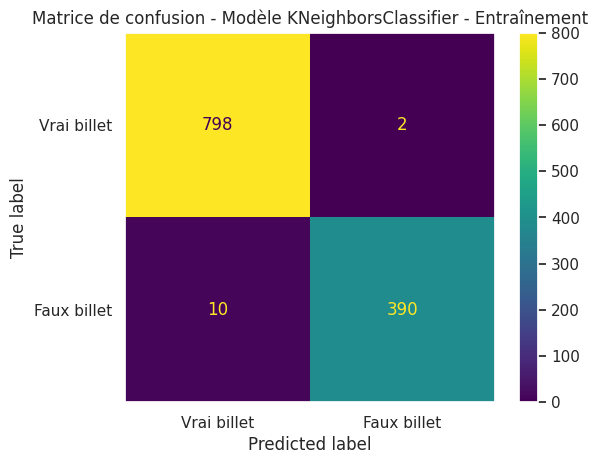

In [56]:
confusion(y_train, y_train_pred_knn, "KNeighborsClassifier", "Entraînement")

              precision    recall  f1-score   support

 Vrai billet       0.99      1.00      1.00       200
 Faux billet       1.00      0.98      0.99       100

    accuracy                           0.99       300
   macro avg       1.00      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300



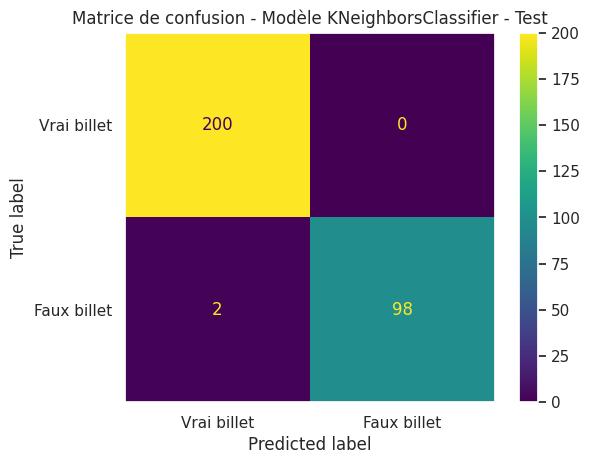

In [57]:
confusion(y_test, y_test_pred_knn, "KNeighborsClassifier", "Test")

In [58]:
y_train_proba_knn = model_knn.predict_proba(X_train)[:,1]
y_test_proba_knn = model_knn.predict_proba(X_test)[:,1]

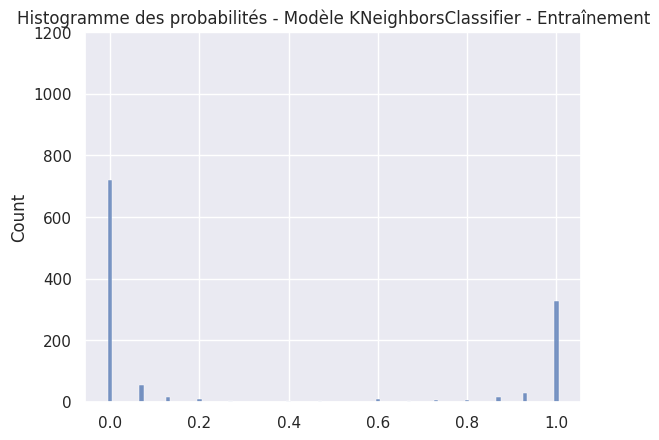

In [59]:
proba_histplot(y_train_proba_knn, "KNeighborsClassifier", "Entraînement")

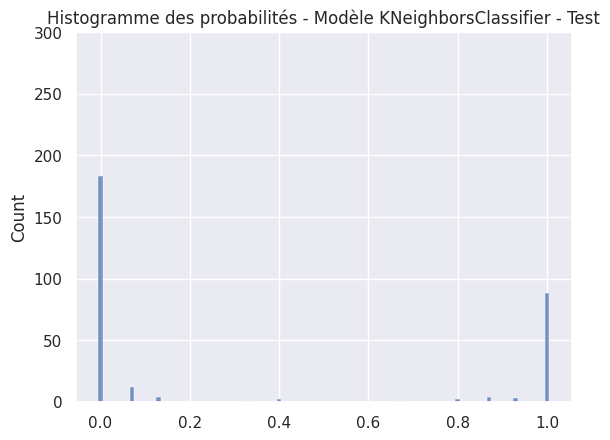

In [60]:
proba_histplot(y_test_proba_knn, "KNeighborsClassifier", "Test")

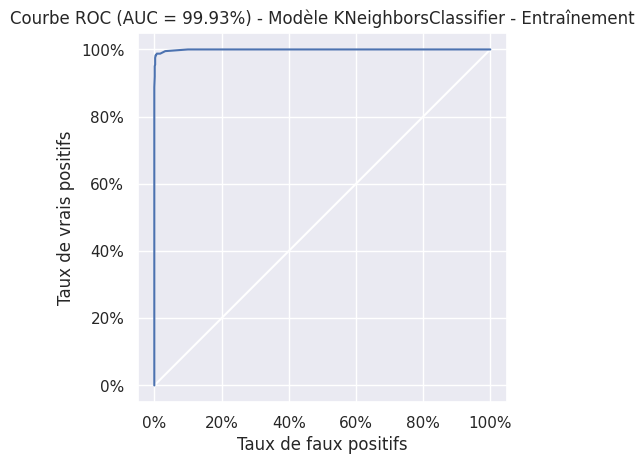

In [61]:
roc_lineplot(y_train, y_train_proba_knn, "KNeighborsClassifier", "Entraînement")

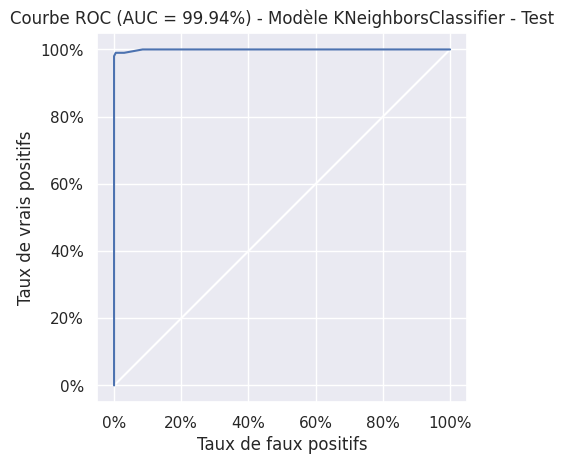

In [62]:
roc_lineplot(y_test, y_test_proba_knn, "KNeighborsClassifier", "Test")

### RandomForestClassifier

In [63]:
from sklearn.ensemble import RandomForestClassifier

In [64]:
model_rf = RandomForestClassifier(max_depth=9, class_weight="balanced", random_state=random_state)
model_rf

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",9
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",100
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 

In [65]:
model_rf.fit(X_train, y_train)
model_rf

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",9
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",100
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 

In [66]:
y_train_pred_rf = model_rf.predict(X_train)
y_test_pred_rf = model_rf.predict(X_test)

              precision    recall  f1-score   support

 Vrai billet       1.00      1.00      1.00       800
 Faux billet       1.00      1.00      1.00       400

    accuracy                           1.00      1200
   macro avg       1.00      1.00      1.00      1200
weighted avg       1.00      1.00      1.00      1200



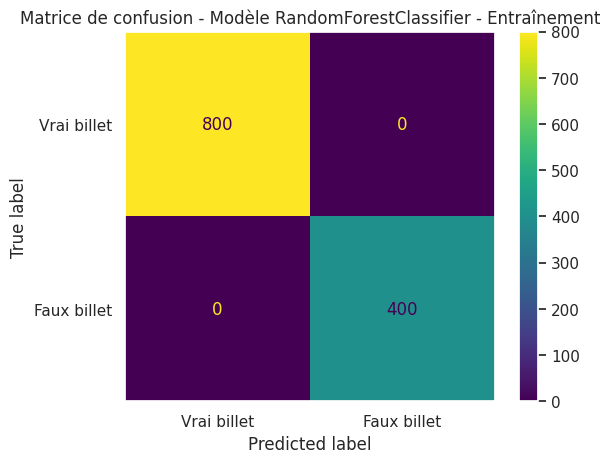

In [67]:
confusion(y_train, y_train_pred_rf, "RandomForestClassifier", "Entraînement")

              precision    recall  f1-score   support

 Vrai billet       1.00      1.00      1.00       200
 Faux billet       1.00      0.99      0.99       100

    accuracy                           1.00       300
   macro avg       1.00      0.99      1.00       300
weighted avg       1.00      1.00      1.00       300



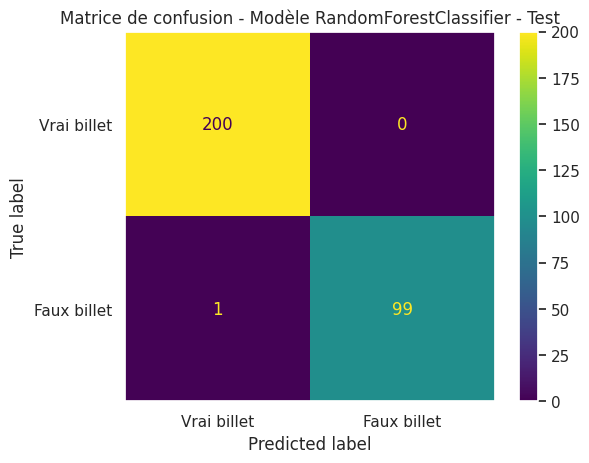

In [68]:
confusion(y_test, y_test_pred_rf, "RandomForestClassifier", "Test")

In [69]:
y_train_proba_rf = model_rf.predict_proba(X_train)[:,1]
y_test_proba_rf = model_rf.predict_proba(X_test)[:,1]

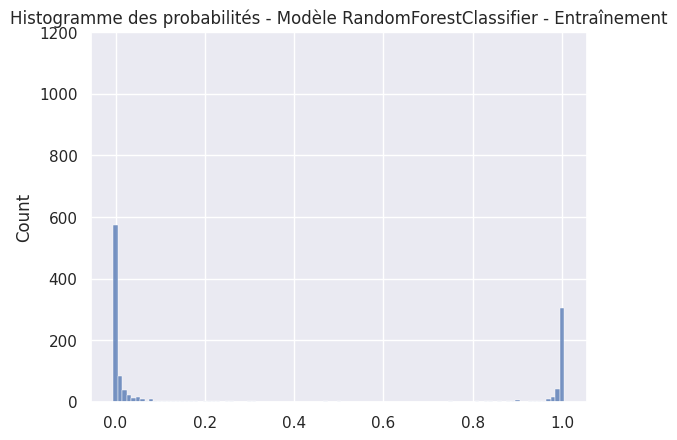

In [70]:
proba_histplot(y_train_proba_rf, "RandomForestClassifier", "Entraînement")

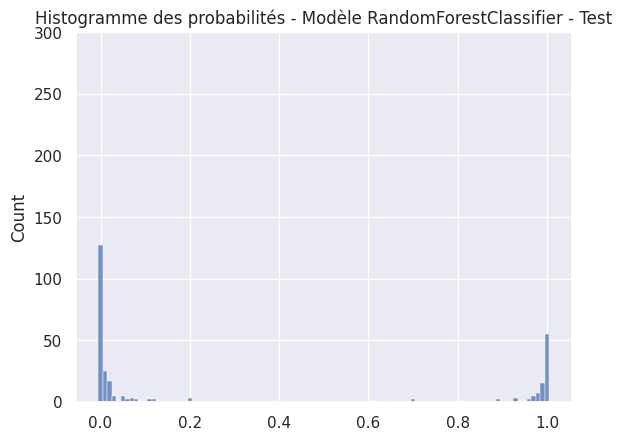

In [71]:
proba_histplot(y_test_proba_rf, "RandomForestClassifier", "Test")

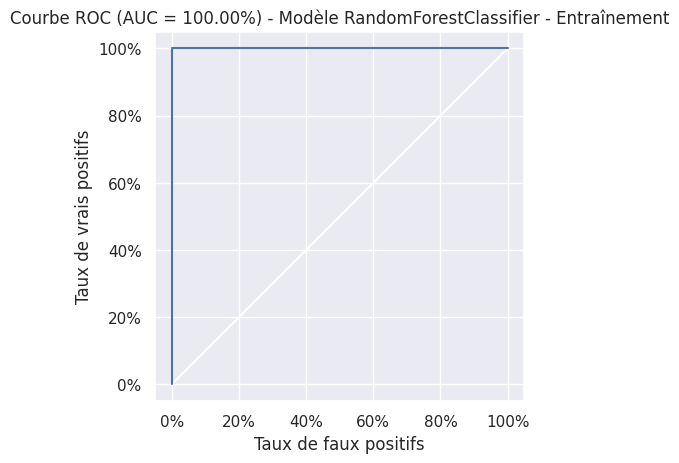

In [72]:
roc_lineplot(y_train, y_train_proba_rf, "RandomForestClassifier", "Entraînement")

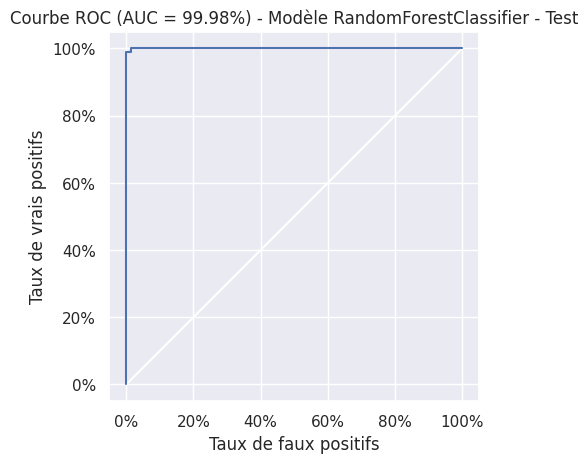

In [73]:
roc_lineplot(y_test, y_test_proba_rf, "RandomForestClassifier", "Test")

## Modèles non-supervisés

### K-means

In [74]:
from sklearn.cluster import KMeans

In [75]:
model_km = KMeans(n_clusters=2, init="random", n_init=1000, random_state=random_state)
model_km

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",2
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'random'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",1000
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",100
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [76]:
model_km.fit(X_train)
model_km

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",2
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'random'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",1000
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",100
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](2, 6)","[[ 0.

In [77]:
y_train_cluster_km = model_km.predict(X_train)
y_test_cluster_km = model_km.predict(X_test)

In [78]:
y_train.groupby(y_train_cluster_km).value_counts()

   is_fake
0  False      792
   True        13
1  True       387
   False        8
Name: count, dtype: int64

In [79]:
y_test.groupby(y_test_cluster_km).value_counts()

   is_fake
0  False      198
   True         1
1  True        99
   False        2
Name: count, dtype: int64

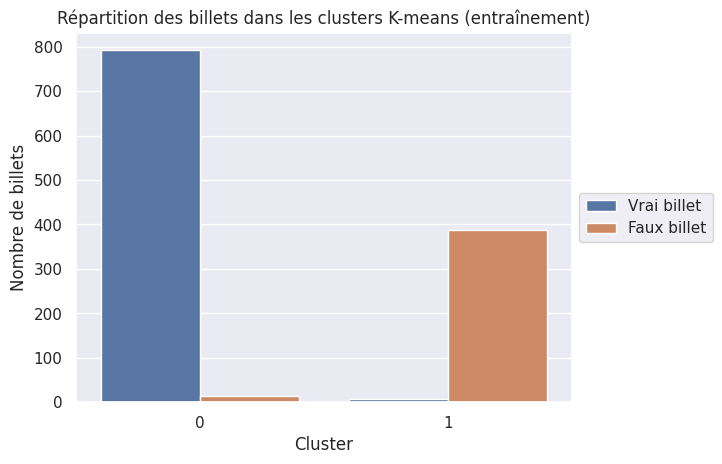

In [80]:
hue = y_train.map(["Vrai billet","Faux billet"].__getitem__)
sns.set(style="darkgrid")
sns.countplot(x=y_train_cluster_km, hue=hue, hue_order=["Vrai billet","Faux billet"])
plt.xlabel("Cluster")
plt.ylabel("Nombre de billets")
plt.title("Répartition des billets dans les clusters K-means (entraînement)")
plt.legend(loc="center left", bbox_to_anchor=(1,0.5))
plt.show()

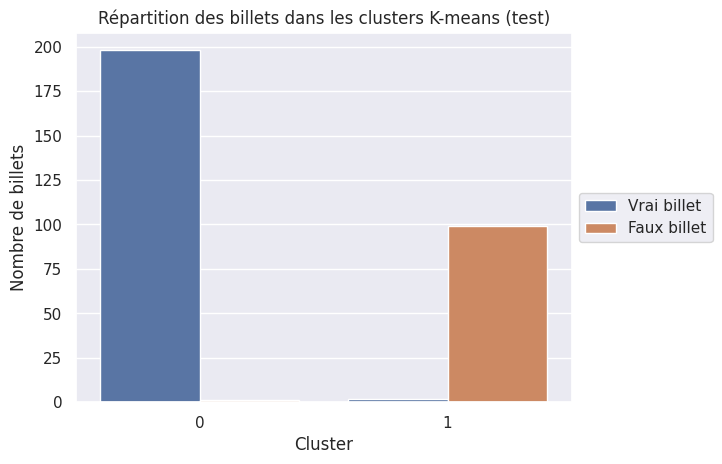

In [81]:
hue = y_test.map(["Vrai billet","Faux billet"].__getitem__)
sns.set(style="darkgrid")
sns.countplot(x=y_test_cluster_km, hue=hue, hue_order=["Vrai billet","Faux billet"])
plt.xlabel("Cluster")
plt.ylabel("Nombre de billets")
plt.title("Répartition des billets dans les clusters K-means (test)")
plt.legend(loc="center left", bbox_to_anchor=(1,0.5))
plt.show()

In [82]:
df_km_mapping = pd.DataFrame({ "is_fake": y_train, "cluster": y_train_cluster_km }, index=y_train.index)
df_km_mapping = df_km_mapping.value_counts(sort=True, ascending=False).reset_index()
df_km_mapping

,is_fake,cluster,count
0,False,0,792
1,True,1,387
2,True,0,13
3,False,1,8


In [83]:
assert df_km_mapping.iloc[:2]["is_fake"].nunique() == 2
assert df_km_mapping.iloc[:2]["cluster"].nunique() == 2

In [84]:
km_y_to_cluster = df_km_mapping.iloc[:2].set_index("is_fake")["cluster"]
km_y_to_cluster

is_fake
False    0
True     1
Name: cluster, dtype: int32

In [85]:
km_cluster_genuine = km_y_to_cluster[False]
km_cluster_fake    = km_y_to_cluster[True ]
print(f"Les vrais billets correspondent au cluster #{km_cluster_genuine}.")
print(f"Les faux billets correspondent au cluster #{km_cluster_fake}.")

Les vrais billets correspondent au cluster #0.
Les faux billets correspondent au cluster #1.


In [86]:
y_train_pred_km = (y_train_cluster_km == km_cluster_fake)
y_test_pred_km = (y_test_cluster_km == km_cluster_fake)

              precision    recall  f1-score   support

 Vrai billet       0.98      0.99      0.99       800
 Faux billet       0.98      0.97      0.97       400

    accuracy                           0.98      1200
   macro avg       0.98      0.98      0.98      1200
weighted avg       0.98      0.98      0.98      1200



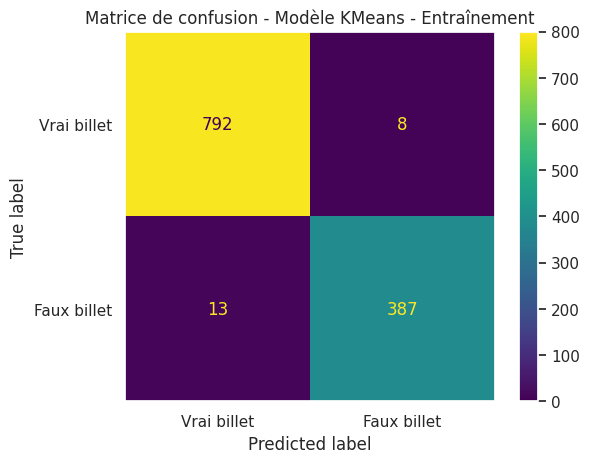

In [87]:
confusion(y_train, y_train_pred_km, "KMeans", "Entraînement")

              precision    recall  f1-score   support

 Vrai billet       0.99      0.99      0.99       200
 Faux billet       0.98      0.99      0.99       100

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300



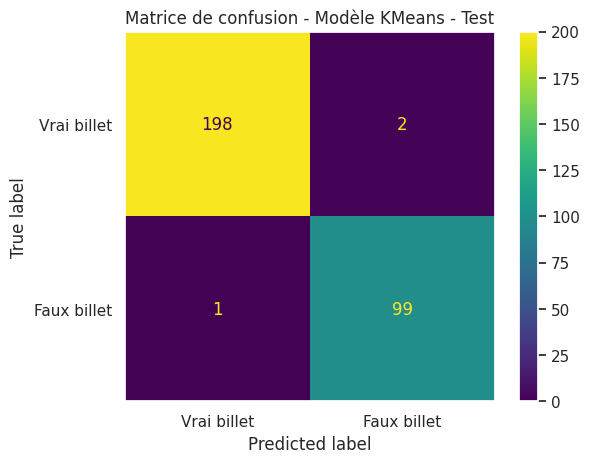

In [88]:
confusion(y_test, y_test_pred_km, "KMeans", "Test")

# Comparaison des modèles

In [89]:
def make_model_comparison(score, model_names, y_train, y_train_args, y_test, y_test_args):
    scores_train = [ score(y_train, y_train_arg) for y_train_arg in y_train_args ]
    scores_test = [ score(y_test, y_test_arg) for y_test_arg in y_test_args ]
    return pd.DataFrame((
        (subset, model_name, score)
        for subset, scores in (("Train", scores_train), ("Test", scores_test))
        for model_name, score in zip(model_names, scores)
    ), columns=["Subset","Model","Score"])

In [90]:
def display_model_comparison(score_name, df):
    # print(df)
    sns.set(style="darkgrid")
    
    fig, ax = plt.subplots(figsize=(8,4))
    sns.barplot(df, hue="Subset", y="Model", x="Score", ax=ax)
    for container in ax.containers:
        plt.bar_label(container, fmt=lambda pct:f"{pct:.2%}", label_type="center", color="white")
    plt.xlim(0, 1)
    plt.xlabel(score_name)
    ax.xaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
    plt.legend(loc="center left", bbox_to_anchor=(1,0.5))
    plt.title(f"Comparaison des modèles - {score_name}")
    plt.show()
    
    fig, ax = plt.subplots(figsize=(8,4))
    sns.barplot(df, hue="Subset", y="Model", x="Score", ax=ax)
    for container in ax.containers:
        plt.bar_label(container, fmt=lambda pct:f"{pct:.2%}", label_type="edge", padding=-54, color="white")
    plt.xlim(0.95, 1)
    plt.xlabel(score_name)
    ax.xaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
    plt.legend(loc="center left", bbox_to_anchor=(1,0.5))
    plt.title(f"Comparaison des modèles - {score_name} (zoom entre 95% et 100%)")
    plt.show()

In [91]:
def compare_models_pred(score_name, score):
    df = make_model_comparison(
        score, [ "LogisticRegression", "KNeighborsClassifier", "RandomForestClassifier", "KMeans" ],
        y_train, [ y_train_pred_lr, y_train_pred_knn, y_train_pred_rf, y_train_pred_km ],
        y_test, [ y_test_pred_lr, y_test_pred_knn, y_test_pred_rf, y_test_pred_km ],
    )
    display_model_comparison(score_name, df)

In [92]:
def compare_models_proba(score_name, score):
    df = make_model_comparison(
        score, [ "LogisticRegression", "KNeighborsClassifier", "RandomForestClassifier" ],
        y_train, [ y_train_proba_lr, y_train_proba_knn, y_train_proba_rf ],
        y_test, [ y_test_proba_lr, y_test_proba_knn, y_test_proba_rf ],
    )
    display_model_comparison(score_name, df)

In [93]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

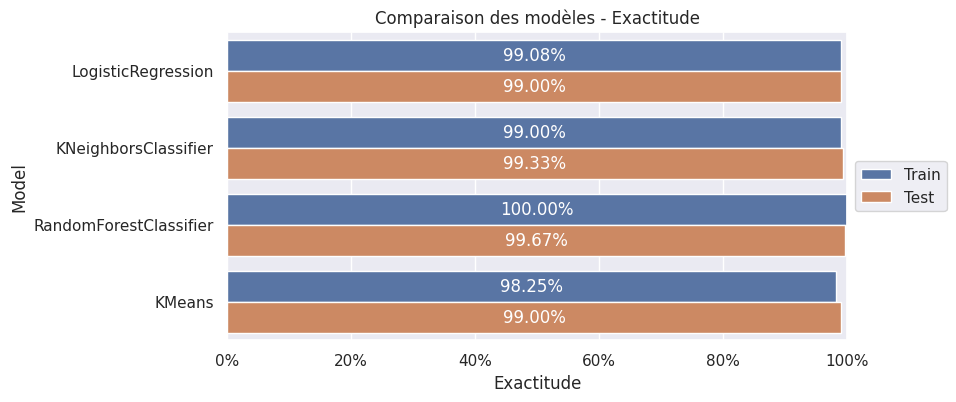

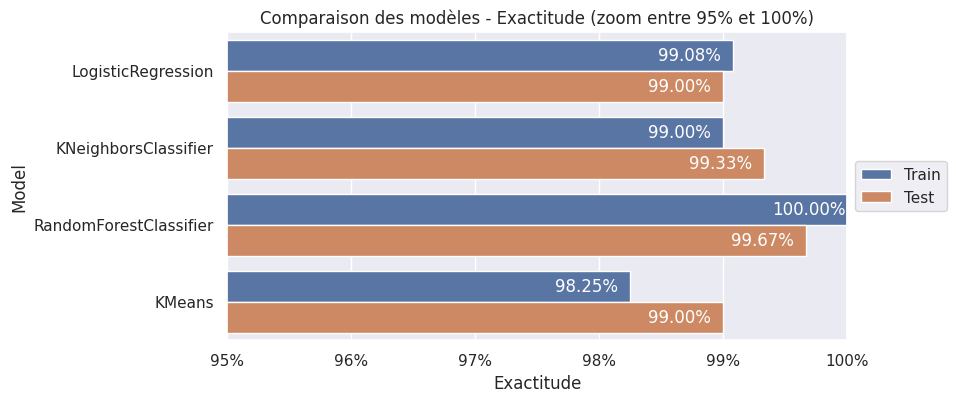

In [94]:
compare_models_pred("Exactitude", accuracy_score)

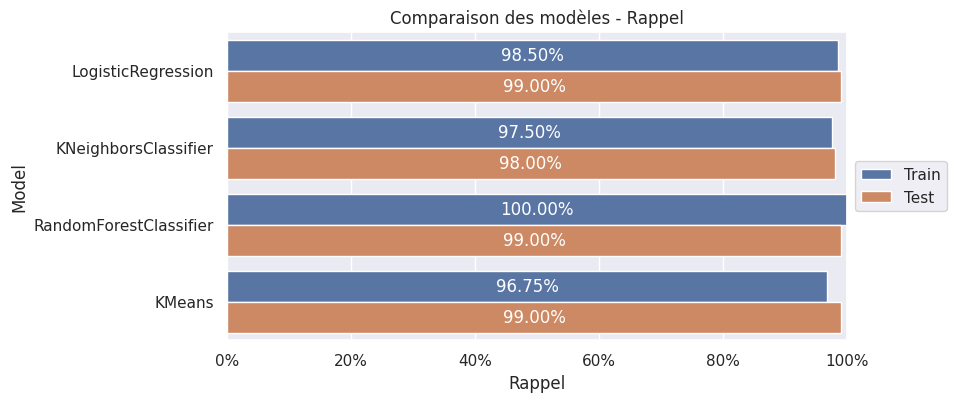

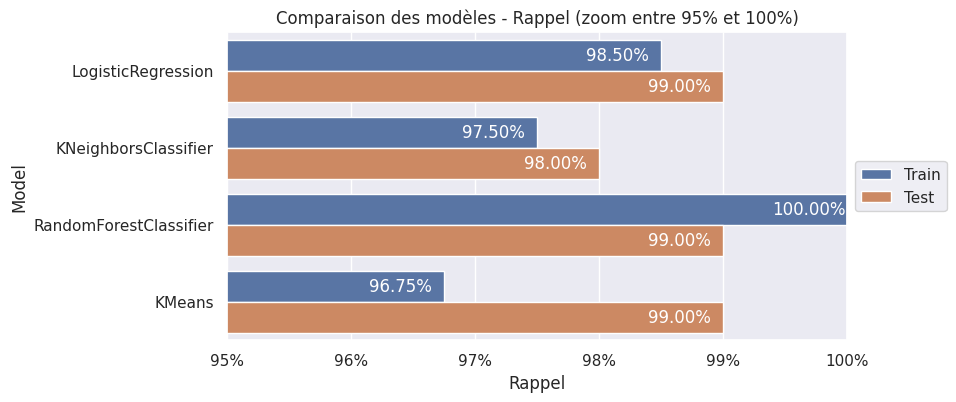

In [95]:
compare_models_pred("Rappel", recall_score)

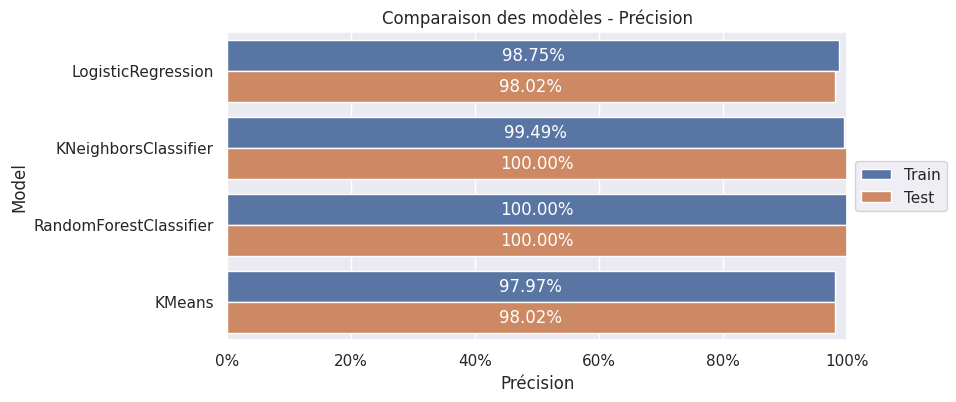

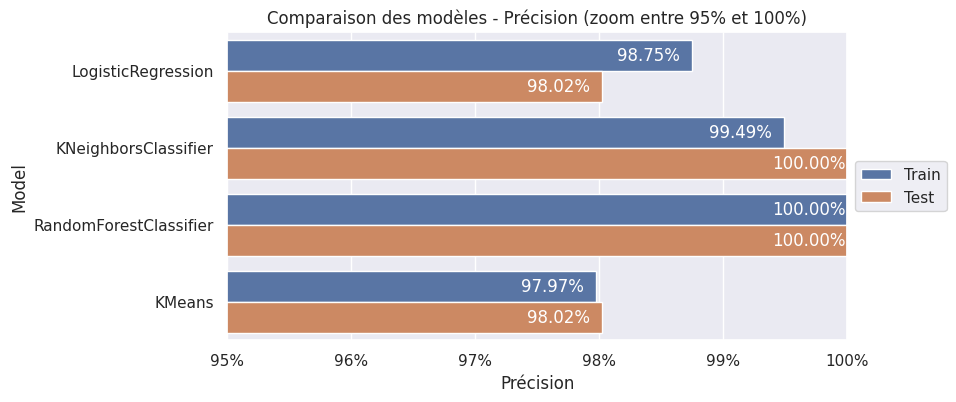

In [96]:
compare_models_pred("Précision", precision_score)

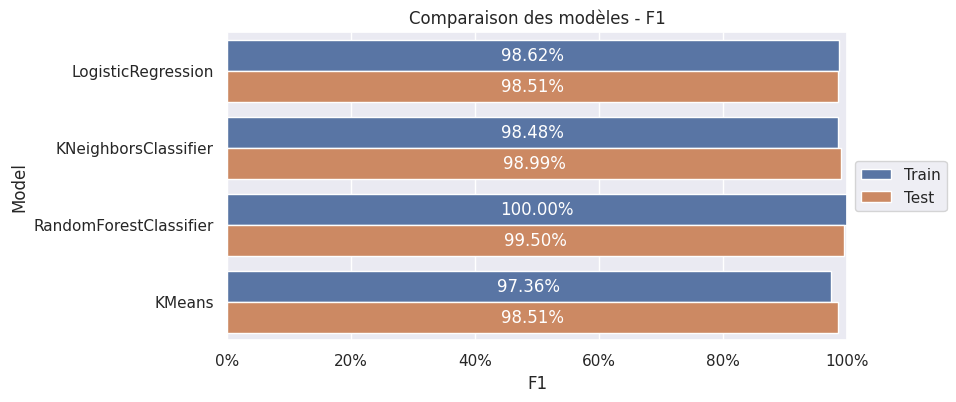

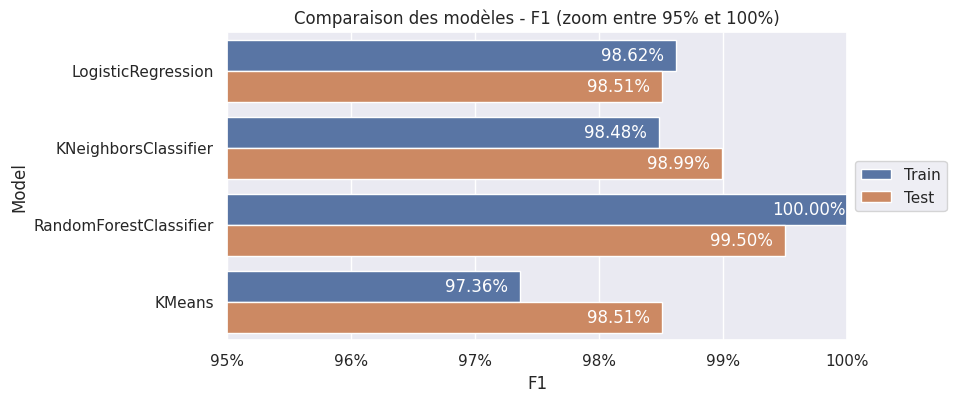

In [97]:
compare_models_pred("F1", f1_score)

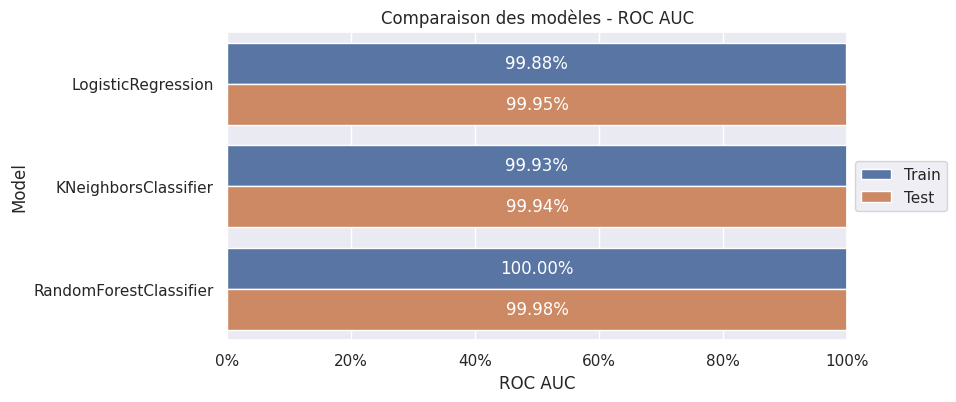

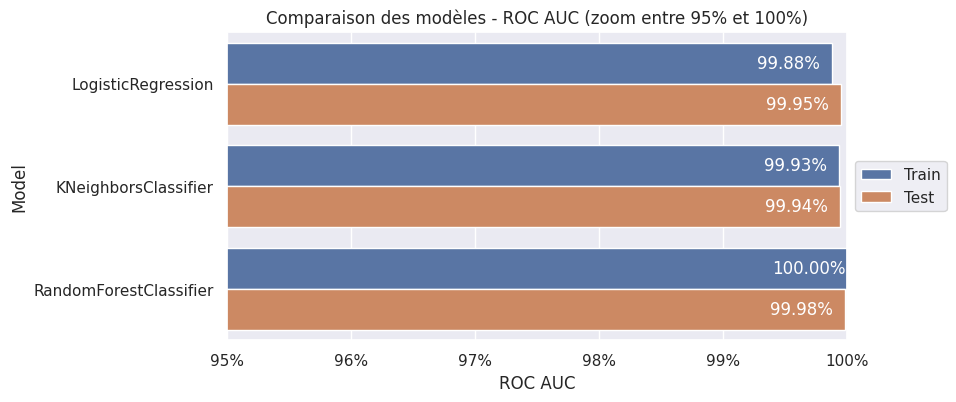

In [98]:
compare_models_proba("ROC AUC", roc_auc_score)

# Sauvegarde des modèles

In [99]:
from sklearn.pipeline import make_pipeline
import joblib

In [100]:
for model_name, model in [
    ("lr" , model_lr ),
    ("knn", model_knn),
    ("rf" , model_rf ),
    ("km" , model_km ),
]:
    pipeline = make_pipeline(imputer, std_scaler, model)
    filename = f"{data_path}/pipelines/{model_name}.joblib"
    joblib.dump(pipeline, filename)